Dispositivo ativo: cuda
468 imagens carregadas

--- IMAGEM ORIGINAL  ---


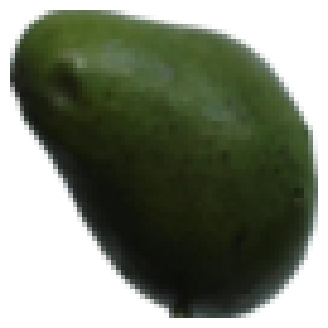

In [72]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo ativo: {device}")
if str(device) == "cpu":
    print (f"")

ABACATE_PATH = "/kaggle/input/datasets/moltean/fruits/fruits-360_original-size/fruits-360-original-size/Training/Avocado Green 1"
class AbacateDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
        print(f"{len(self.image_files)} imagens carregadas")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0

BATCH_SIZE = 64
LATENT_DIM = 128 #Aumento para 128 para dar mais margem de variação do abacate
IMAGE_SIZE = 64  
CHANNELS = 3     
EPOCHS = 20
LR = 0.0002 #Taxa de aprendizado equilibrada

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

dataset_abacate = AbacateDataset(folder_path=ABACATE_PATH, transform=transform)
dataloader = DataLoader(dataset_abacate, batch_size=BATCH_SIZE, shuffle=True)

def imshow(img, title=""):
    img = img / 2 + 0.5  #Desnormalizar para exibir RGB correto
    plt.figure(figsize=(4, 4))
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()
dataiter = iter(dataloader)
images, _ = next(dataiter)
imagem_original_cobaia = images[0].to(device)

print("\n--- IMAGEM ORIGINAL  ---")
imshow(images[0].cpu(), title="")

In [73]:
# Arquitetura do VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(CHANNELS, 32, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),       
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),      
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )
        
        self.fc_mu = nn.Linear(128 * 8 * 8, LATENT_DIM)
        self.fc_logvar = nn.Linear(128 * 8 * 8, LATENT_DIM)
        
        #poder de desenho ao gerador pra bagaçar as imagens
        self.decoder_input = nn.Linear(LATENT_DIM, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, CHANNELS, kernel_size=4, stride=2, padding=1), 
            nn.Tanh() 
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        z_projected = self.decoder_input(z).view(-1, 128, 8, 8)
        reconstructed = self.decoder(z_projected)
        return reconstructed, mu, logvar

# Discriminador sem BatchNorm e reduzido filtros para que ele não acerte TUDO(a ideia é o equilíbrio) 
class Discriminador(nn.Module):
    def __init__(self):
        super(Discriminador, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(CHANNELS, 16, kernel_size=4, stride=2, padding=1), #32 para 16
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),       #64 para 32
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.model(x)

vae = VAE().to(device)
discriminator = Discriminador().to(device)


optimizer_vae = optim.Adam(vae.parameters(), lr=0.0003, betas=(0.5, 0.999))
optimizer_disc = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
criterion_bce = nn.BCELoss()

loss_history_vae = []
loss_history_disc = []
print("Forças do gerador e classificador em equilíbrio")

Forças do gerador e classificador em equilíbrio


In [74]:
print("--- TREINAMENTO COM GERADOR ---")

for epoch in range(EPOCHS):
    epoch_vae_loss = 0
    epoch_disc_loss = 0
    
    vae.train()
    discriminator.train()
    
    for imgs, _ in dataloader:
        batch_size_current = imgs.size(0)
        real_imgs = imgs.to(device)
        
        #labels mais agressivas para confundir o classificador
        label_real = torch.full((batch_size_current, 1), 0.85, device=device) 
        label_fake = torch.full((batch_size_current, 1), 0.15, device=device) 
        
        #Treino do Discriminador
        optimizer_disc.zero_grad()
        outputs_real = discriminator(real_imgs)
        loss_real = criterion_bce(outputs_real, label_real)
        
        reconstructed_imgs, mu, logvar = vae(real_imgs)
        outputs_fake = discriminator(reconstructed_imgs.detach())
        loss_fake = criterion_bce(outputs_fake, label_fake)
        
        loss_d = loss_real + loss_fake
        loss_d.backward()
        optimizer_disc.step()
        
        #Treino do VAE/Gerador (foco em enganar a IA)
        optimizer_vae.zero_grad()
        loss_reconstruction = nn.MSELoss()(reconstructed_imgs, real_imgs)
        loss_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size_current
        
        outputs_vae_adversarial = discriminator(reconstructed_imgs)
        loss_adversarial = criterion_bce(outputs_vae_adversarial, torch.ones((batch_size_current, 1), device=device))
        
        #ajuste de 0.05 para 0.50
        loss_v = loss_reconstruction + 0.005 * loss_kl + 0.50 * loss_adversarial
        loss_v.backward()
        optimizer_vae.step()
        
        epoch_vae_loss += loss_v.item()
        epoch_disc_loss += loss_d.item()
        
    loss_history_vae.append(epoch_vae_loss / len(dataloader))
    loss_history_disc.append(epoch_disc_loss / len(dataloader))
    print(f"Época [{epoch+1:02d}/{EPOCHS}] | Loss VAE: {loss_history_vae[-1]:.4f} | Loss Disc: {loss_history_disc[-1]:.4f}")

--- TREINAMENTO COM GERADOR ---
Época [01/20] | Loss VAE: 1.1679 | Loss Disc: 1.3765
Época [02/20] | Loss VAE: 0.9464 | Loss Disc: 1.4320
Época [03/20] | Loss VAE: 0.8676 | Loss Disc: 1.4668
Época [04/20] | Loss VAE: 0.6763 | Loss Disc: 1.4980
Época [05/20] | Loss VAE: 0.6080 | Loss Disc: 1.4847
Época [06/20] | Loss VAE: 0.5789 | Loss Disc: 1.4689
Época [07/20] | Loss VAE: 0.5728 | Loss Disc: 1.4521
Época [08/20] | Loss VAE: 0.5973 | Loss Disc: 1.4327
Época [09/20] | Loss VAE: 0.5593 | Loss Disc: 1.4215
Época [10/20] | Loss VAE: 0.5745 | Loss Disc: 1.4124
Época [11/20] | Loss VAE: 0.5391 | Loss Disc: 1.4040
Época [12/20] | Loss VAE: 0.5177 | Loss Disc: 1.3986
Época [13/20] | Loss VAE: 0.5050 | Loss Disc: 1.3936
Época [14/20] | Loss VAE: 0.4959 | Loss Disc: 1.3904
Época [15/20] | Loss VAE: 0.5006 | Loss Disc: 1.3881
Época [16/20] | Loss VAE: 0.5067 | Loss Disc: 1.3901
Época [17/20] | Loss VAE: 0.5183 | Loss Disc: 1.3866
Época [18/20] | Loss VAE: 0.5041 | Loss Disc: 1.3859
Época [19/20] 

--- VARIANTES COM ESTRUTURA BAGAÇADA ---


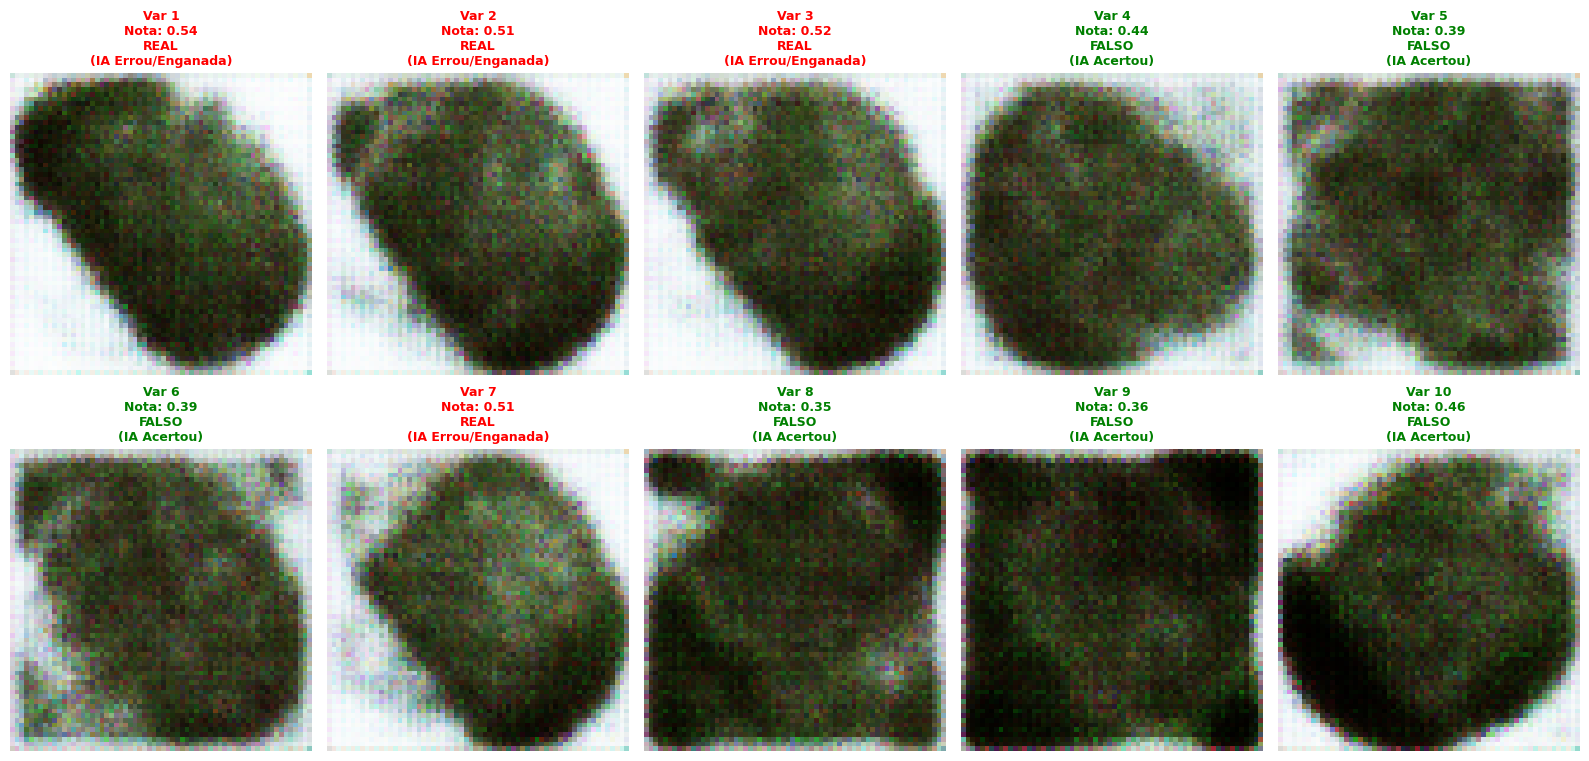

In [75]:
print("--- VARIANTES COM ESTRUTURA BAGAÇADA ---")
vae.eval()
discriminator.eval()

with torch.no_grad():
    hidden_cobaia = vae.encoder(imagem_original_cobaia.unsqueeze(0))
    mu_cobaia = vae.fc_mu(hidden_cobaia)
    logvar_cobaia = vae.fc_logvar(hidden_cobaia)
    
    plt.figure(figsize=(16, 8))
    
    for idx in range(10):
        z_baguncado = vae.reparameterize(mu_cobaia, logvar_cobaia)
        
        # Engenharia da bagunça
        if idx >= 3:
            ponto_corte = LATENT_DIM // 2
            z_baguncado[:, :ponto_corte] = torch.flip(z_baguncado[:, :ponto_corte], dims=[1])
        if idx >= 7:
            z_baguncado[:, ponto_corte:] = z_baguncado[:, ponto_corte:] * -1.5
        
        z_projected = vae.decoder_input(z_baguncado).view(1, 128, 8, 8)
        imagem_generated = vae.decoder(z_projected)
        
        nota_discriminador = discriminator(imagem_generated).item()
        
        if nota_discriminador > 0.5:
            veredicto = "REAL\n(IA Errou/Enganada)"
            cor_titulo = 'red'
        else:
            veredicto = "FALSO\n(IA Acertou)"
            cor_titulo = 'green'
        
        img_plot = imagem_generated.squeeze(0).cpu() / 2 + 0.5
        img_plot = torch.clamp(img_plot, 0, 1)
        
        plt.subplot(2, 5, idx + 1)
        plt.imshow(np.transpose(img_plot.numpy(), (1, 2, 0)))
        
        plt.title(f"Var {idx+1}\nNota: {nota_discriminador:.2f}\n{veredicto}", fontsize=9, color=cor_titulo, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

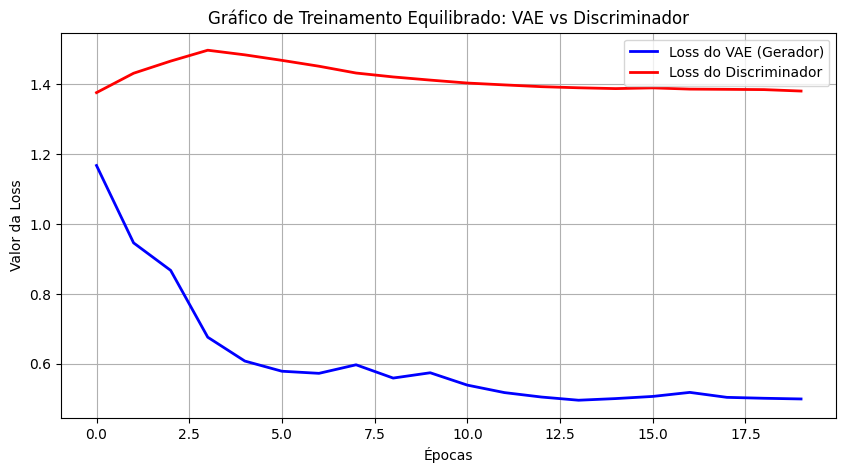

In [76]:

plt.figure(figsize=(10, 5))
plt.plot(loss_history_vae, label="Loss do VAE (Gerador)", color='blue', linewidth=2)
plt.plot(loss_history_disc, label="Loss do Discriminador", color='red', linewidth=2)
plt.xlabel("Épocas")
plt.ylabel("Valor da Loss")
plt.title("Gráfico de Treinamento Equilibrado: VAE vs Discriminador")
plt.legend()
plt.grid(True)
plt.show()